# Model Comparison

## Setup

In [18]:
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_squared_error , r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [19]:
# Load arrays from the compressed archive
data = np.load('datasets/processed_splits.npz')

X_tr_scaled = data['X_tr']
y_tr_scaled = data['y_tr_scaled']
y_tr = data['y_tr']
X_val_scaled = data['X_val']
y_val = data['y_val']
X_test_scaled = data['X_test_scaled']
y_test = data['y_test']

# import exact scaler instance from the preprocessing notebook
target_scaler = joblib.load('datasets/target_scaler.joblib')

# import optimized models
ridge_model = joblib.load('models/ridge_model.joblib')
rf_model = joblib.load('models/rf_model.joblib')
mlp_model = models.load_model('models/mlp_model.keras')

print('All data successfully imported.')


All data successfully imported.


## Predict on Test Set

 Run all models on test set

In [20]:
# ridge regression
y_pred_ridge_test_scaled = ridge_model.predict(X_test_scaled)
y_pred_ridge_test = target_scaler.inverse_transform(y_pred_ridge_test_scaled)


In [21]:
# # random forest regressor
y_pred_rf_test_scaled = rf_model.predict(X_test_scaled)
y_pred_rf_test = target_scaler.inverse_transform(y_pred_rf_test_scaled)


In [22]:
# multilayer perceptron
y_pred_mlp_test_scaled = mlp_model.predict(X_test_scaled)
y_pred_mlp_test = target_scaler.inverse_transform(y_pred_mlp_test_scaled)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [23]:
# initialize lists of model names and targets
model_names = ('Ridge', 'Random Forest', 'MLP')
coefficients = ('Kappa', 'Beta')


## Plot of R^2 values

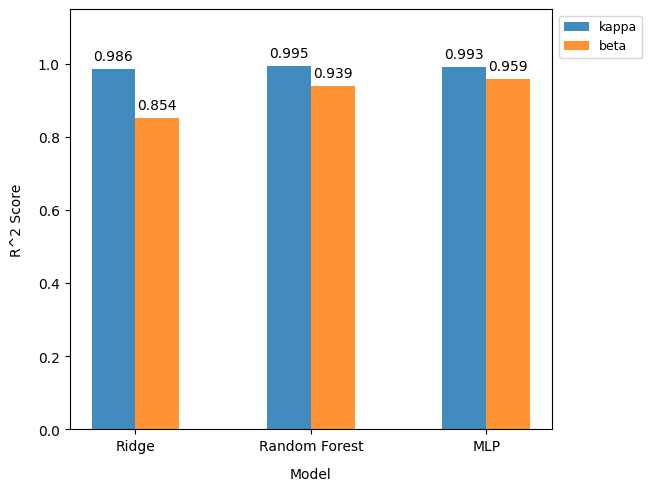

In [24]:
# save all R^2 values for Ridge, RF and MLP models
r2_values = {
    'kappa': (
        r2_score(y_test[:,0], y_pred_ridge_test[:,0]),
        r2_score(y_test[:,0], y_pred_rf_test[:,0]),
        r2_score(y_test[:,0], y_pred_mlp_test[:,0])
    ),
    'beta': (
        r2_score(y_test[:,1], y_pred_ridge_test[:,1]),
        r2_score(y_test[:,1], y_pred_rf_test[:,1]),
        r2_score(y_test[:,1], y_pred_mlp_test[:,1])
    )
}

# initialize and build bar chart comparing r^2 scores between models
x = np.arange(len(model_names))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for param_name, scores in r2_values.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, scores, width, label=param_name, alpha=0.85)

    
    ax.bar_label(rects, padding=4, fmt='%.3f')
    multiplier += 1

ax.set_ylabel('R^2 Score', labelpad=10)
ax.set_xlabel('Model', labelpad=10)

ax.set_xticks(x + width / 2, model_names)
ax.set_ylim(0, 1.15)
ax.legend(bbox_to_anchor=(1.2, 1) , fontsize=9)

plt.show()

## Summary of scatter plots

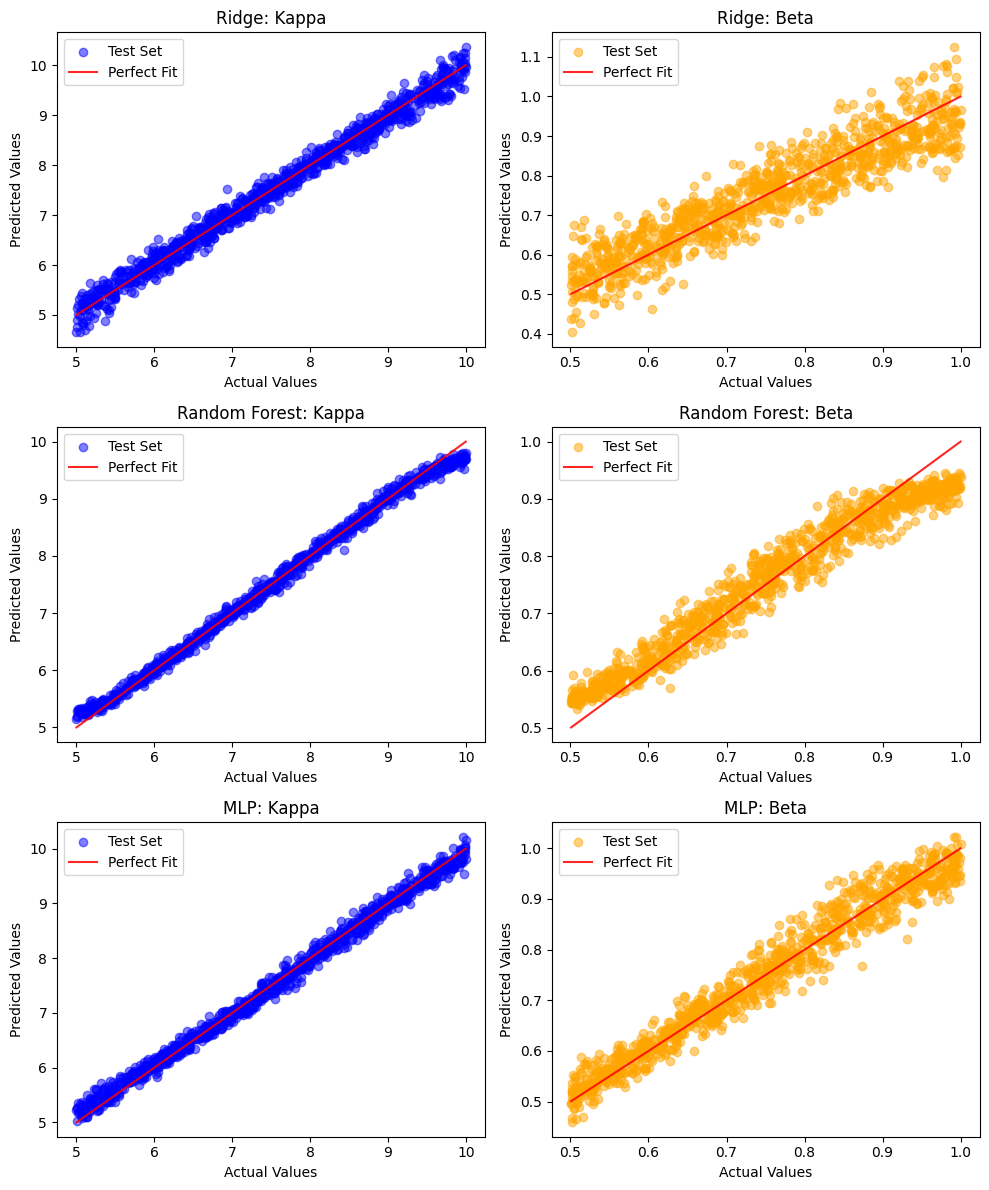

In [30]:
fig, axs = plt.subplots(3, 2, figsize=(10, 12))
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

ax1.scatter(y_test[:,0], y_pred_ridge_test[:,0], color='blue', alpha=0.5, label='Test Set')
ax2.scatter(y_test[:,1], y_pred_ridge_test[:,1], color='orange', alpha=0.5, label='Test Set')

ax3.scatter(y_test[:,0], y_pred_rf_test[:,0], color='blue', alpha=0.5, label='Test Set')
ax4.scatter(y_test[:,1], y_pred_rf_test[:,1], color='orange', alpha=0.5, label='Test Set')

ax5.scatter(y_test[:,0], y_pred_mlp_test[:,0], color='blue', alpha=0.5, label='Test Set')
ax6.scatter(y_test[:,1], y_pred_mlp_test[:,1], color='orange', alpha=0.5, label='Test Set')

# generate scatter plots for kappa and beta for each model side by side
for row in range(3):
    for col in range(2):
        # generate perfect fit line y=x
        perf_fit_line = np.linspace(min(y_test[:,col]), max(y_test[:,col]), 100)
        axs[row, col].plot(perf_fit_line, perf_fit_line, color='red', alpha=0.85, label='Perfect Fit')

        axs[row, col].set_title(model_names[row] + ': ' + coefficients[col])
        axs[row, col].set_xlabel('Actual Values')
        axs[row, col].set_ylabel('Predicted Values')
        axs[row, col].legend()


plt.tight_layout()
plt.show()


## Residuals plots

In [26]:
# calculate the residuals for each model
ridge_res = y_test - y_pred_ridge_test
rf_res = y_test - y_pred_rf_test
mlp_res = y_test - y_pred_mlp_test


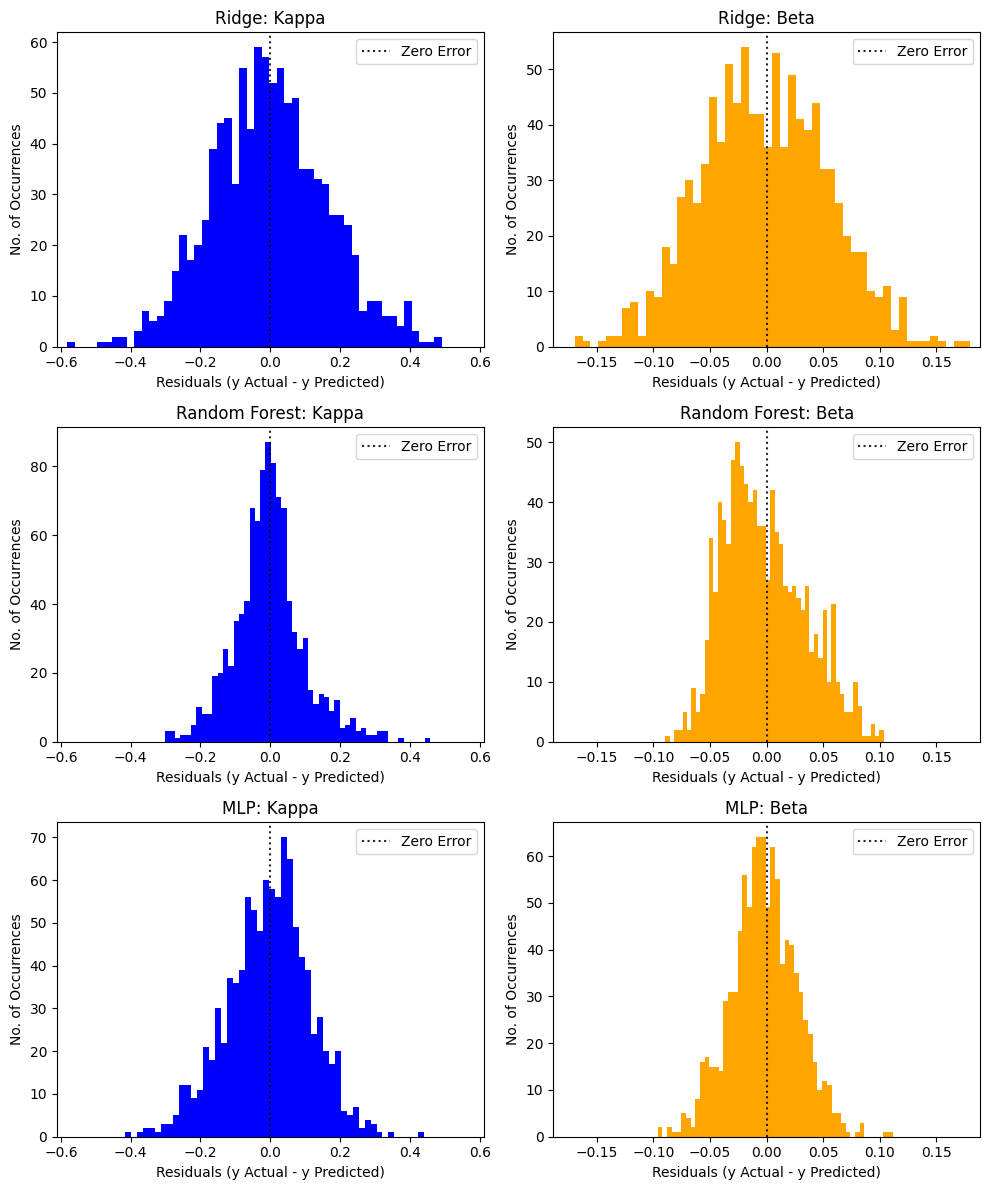

In [47]:
fig, axs = plt.subplots(3, 2, figsize=(10, 12))
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

ax1.hist(ridge_res[:,0], bins=50, color='blue')
ax2.hist(ridge_res[:,1], bins=50, color='orange')

ax3.hist(rf_res[:,0], bins=50, color='blue') 
ax4.hist(rf_res[:,1], bins=50, color='orange')

ax5.hist(mlp_res[:,0], bins=50, color='blue')
ax6.hist(mlp_res[:,1], bins=50, color='orange')

# define ranges for plots (use Ridge model as basis as it tends to have the widest range of residuals)
k_lim = max(np.abs(ridge_res[:,0])) * 1.05
b_lim = max(np.abs(ridge_res[:,1])) * 1.05

for row in range(3):
    for col in range(2):
        # plot a reference line of zero error (perfect model)
        axs[row, col].axvline(x=0, color='black', linestyle=':', alpha=0.85, label='Zero Error')

        axs[row, col].set_title(model_names[row] + ': ' + coefficients[col])
        axs[row, 0].set_xlim(-k_lim, k_lim)
        axs[row, 1].set_xlim(-b_lim, b_lim)
        axs[row, col].set_xlabel('Residuals (y Actual - y Predicted)')
        axs[row, col].set_ylabel('No. of Occurrences')
        axs[row, col].legend()

plt.tight_layout()
plt.show()
